# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [4]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

# 1. Vendite maggiori di 10
print(sales.query("sales > 10"))

# 2. Dati del 2018
print(sales.query("year == 2018"))

# 3. Vendite maggiori di 13 con anno 2018
print(sales.query("sales > 13 and year == 2018"))

# 4. Il contrario di prima
print(sales.query("not (sales > 13 and year == 2018)"))

# 5. Vendite divise per 3 maggiori di 3
print(sales.query("sales / 3 > 3"))

# 6. Dipendenti con nome alfabeticamente dopo la J
print(sales.query('employee > "J"'))

  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
  employee  sales  year
0  Katrina     14  2018
3    Roman     12  2018
  employee  sales  year
0  Katrina     14  2018
     employee  sales  year
1      Guanyu     17  2019
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019
6   Esperanza      7  2019
7      Alaina     15  2020
8      Egweyn      5  2020
  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
     employee  sales  year
0     Katrina     14  2018
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

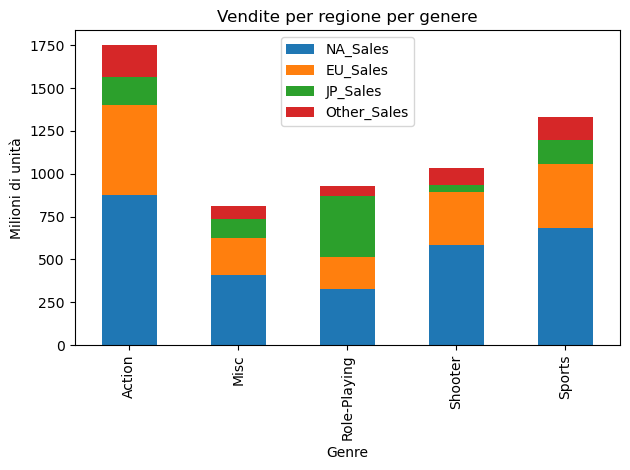


16598
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


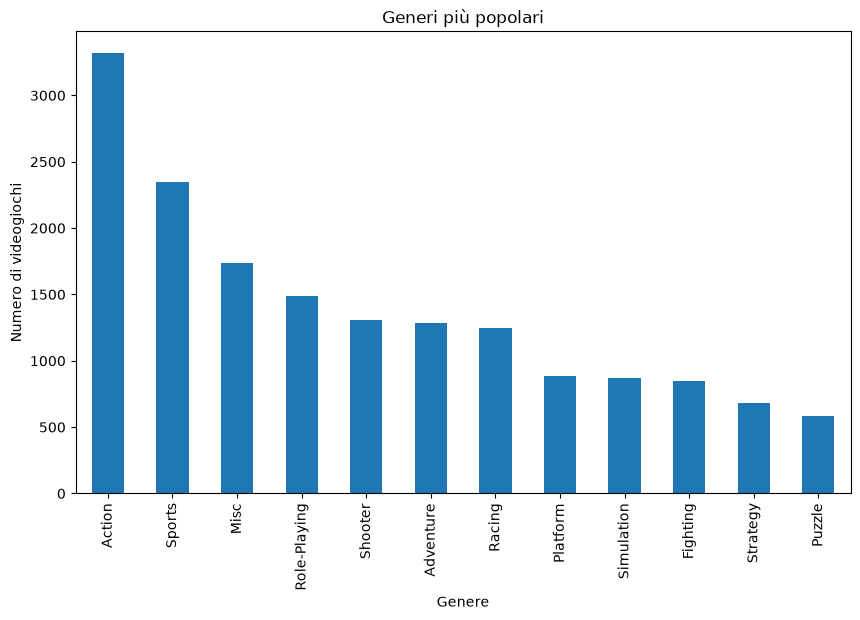

Year
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     349
2001.0     482
2002.0     829
2003.0     775
2004.0     763
2005.0     941
2006.0    1008
2007.0    1202
2008.0    1428
2009.0    1431
2010.0    1259
2011.0    1139
2012.0     657
2013.0     546
2014.0     582
2015.0     614
2016.0     344
2017.0       3
2020.0       1
dtype: int64


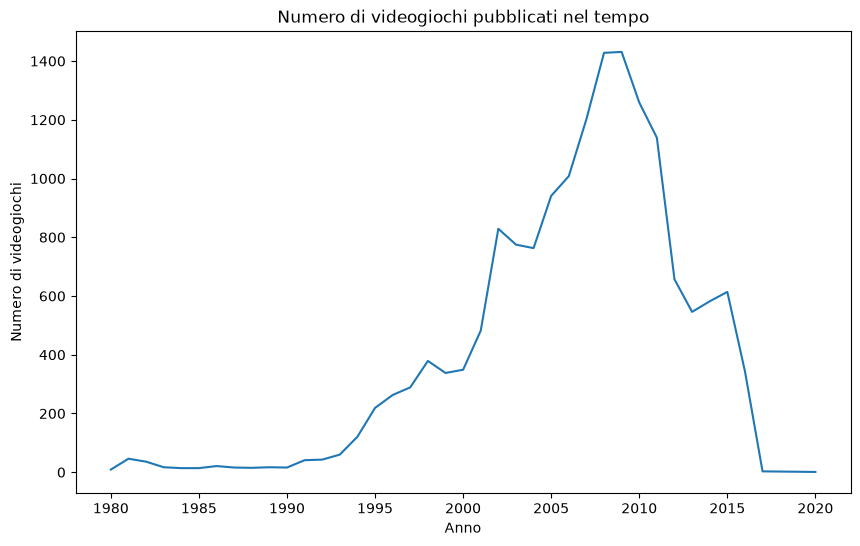

Index(['Action', 'Sports', 'Misc', 'Role-Playing', 'Shooter'], dtype='str', name='Genre')
              NA_Sales  EU_Sales  JP_Sales  Other_Sales
Genre                                                  
Action          877.83    525.00    159.95       187.38
Misc            410.24    215.98    107.76        75.32
Role-Playing    327.28    188.06    352.31        59.61
Shooter         582.60    313.27     38.28       102.69
Sports          683.35    376.85    135.37       134.97


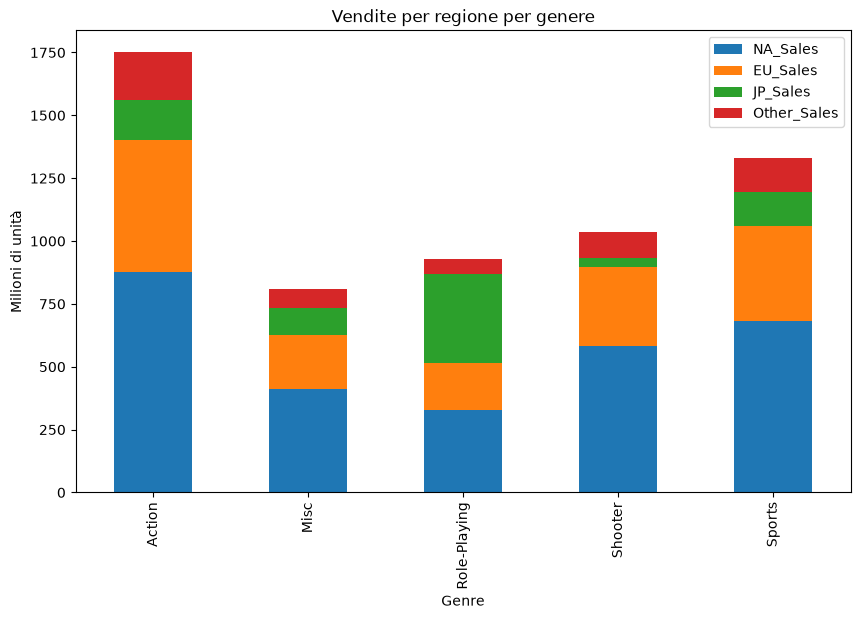

In [5]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

# Videogiochi pubblicati
print(df.shape[0])

# Preparo i dati per il bar plot
generi = df["Genre"].value_counts()

print(generi)

generi.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Genere")
plt.ylabel("Numero di videogiochi")
plt.title("Generi più popolari")

plt.show()

# Preparo i dati per plottare
giochi_per_anno = (
    df.groupby("Year")
    .size()
    .sort_index()
)

print(giochi_per_anno)

giochi_per_anno.plot(
    kind="line",
    figsize=(10, 6)
)

plt.xlabel("Anno")
plt.ylabel("Numero di videogiochi")
plt.title("Numero di videogiochi pubblicati nel tempo")

plt.show()

# Riproducendo il grafico, prendendo i tpo5 generi e le regioni
top5_generi = df["Genre"].value_counts().head(5).index

print(top5_generi)

df_top5 = df[df["Genre"].isin(top5_generi)]

vendite_genere = df_top5.groupby("Genre")[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum()

print(vendite_genere)

vendite_genere.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Genre")
plt.ylabel("Milioni di unità")
plt.title("Vendite per regione per genere")

plt.show()